# Bike Sharing Demand Prediction
Predicting hourly bike rentals using the UCI Bike Sharing Dataset. Target variable is `cnt` (total rentals per hour). Two models are compared: Random Forest and SARIMA.

## Setup

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import zipfile
import urllib.request

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## Data Loading

In [2]:
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

ZIP_PATH = 'data/raw/bike+sharing+dataset.zip'
HOUR_CSV = 'data/raw/hour.csv'

if not os.path.exists(HOUR_CSV):
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    urllib.request.urlretrieve(url, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('data/raw')

df = pd.read_csv(HOUR_CSV)
print(df.shape)
print(list(df.columns))

(17379, 17)
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


## Exploratory Data Analysis

In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicates: 0


In [4]:
print('Target variable (cnt) summary:')
print(df['cnt'].describe())

Target variable (cnt) summary:
count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


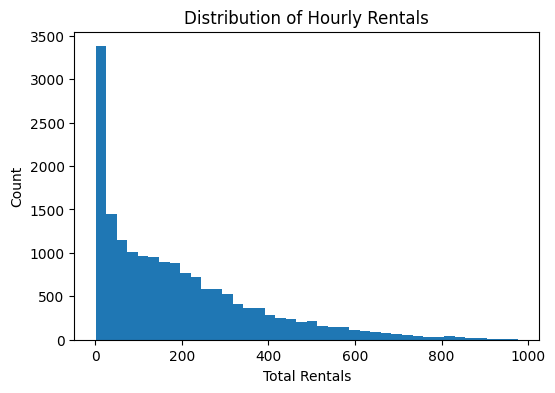

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(df['cnt'], bins=40)
plt.title('Distribution of Hourly Rentals')
plt.xlabel('Total Rentals')
plt.ylabel('Count')
plt.show()

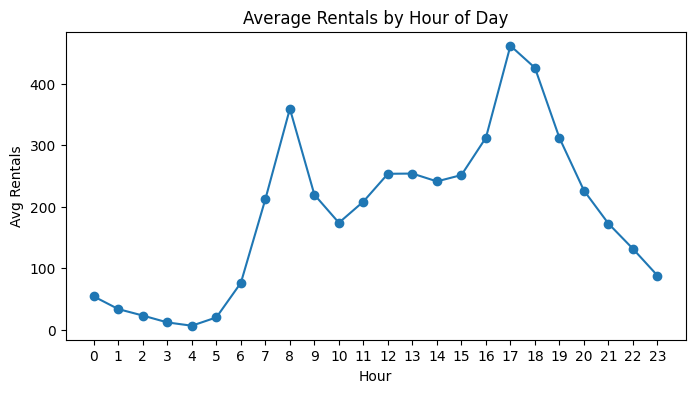

In [6]:
hourly_avg = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Rentals')
plt.xticks(range(0, 24))
plt.show()

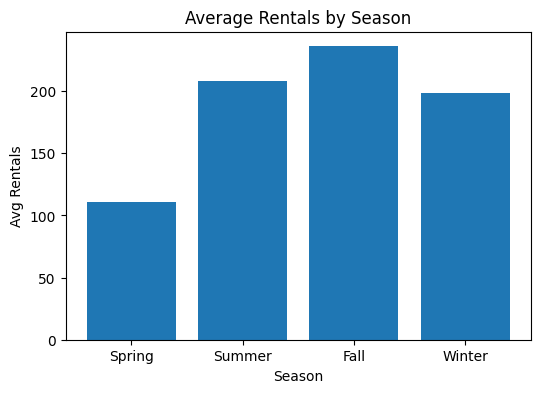

season_label
Spring    111.1
Summer    208.3
Fall      236.0
Winter    198.9
Name: cnt, dtype: float64


In [7]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_label'] = df['season'].map(season_map)
season_avg = df.groupby('season_label')['cnt'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])

plt.figure(figsize=(6, 4))
plt.bar(season_avg.index, season_avg.values)
plt.title('Average Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Avg Rentals')
plt.show()

print(season_avg.round(1))

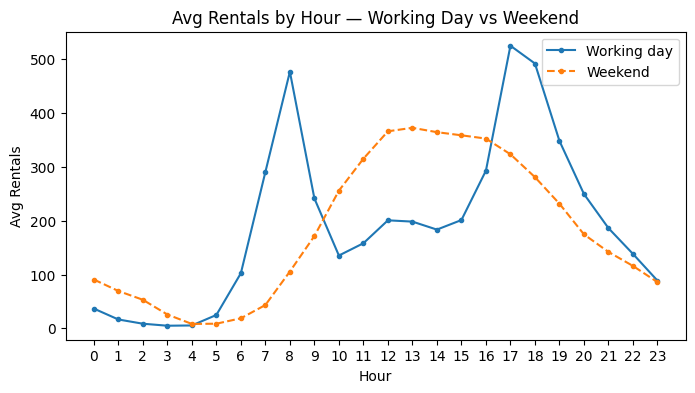

In [8]:
# working day vs weekend shows the commuter pattern clearly
working = df[df['workingday']==1].groupby('hr')['cnt'].mean()
weekend = df[df['workingday']==0].groupby('hr')['cnt'].mean()

plt.figure(figsize=(8, 4))
plt.plot(working.index, working.values, marker='o', markersize=3, label='Working day')
plt.plot(weekend.index, weekend.values, marker='o', markersize=3, linestyle='--', label='Weekend')
plt.title('Avg Rentals by Hour — Working Day vs Weekend')
plt.xlabel('Hour')
plt.ylabel('Avg Rentals')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

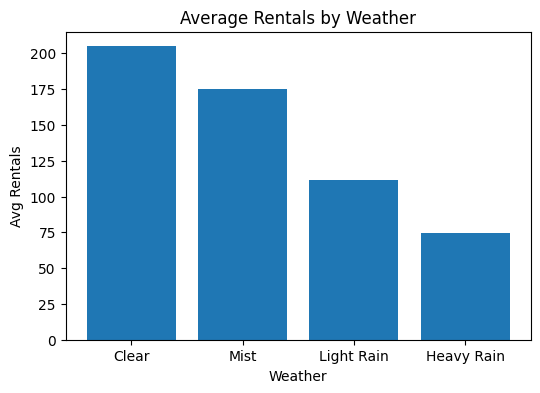

Clear         204.9
Mist          175.2
Light Rain    111.6
Heavy Rain     74.3
Name: cnt, dtype: float64


In [9]:
# weather impact
weather_avg = df.groupby('weathersit')['cnt'].mean()
weather_avg.index = ['Clear', 'Mist', 'Light Rain', 'Heavy Rain']

plt.figure(figsize=(6, 4))
plt.bar(weather_avg.index, weather_avg.values)
plt.title('Average Rentals by Weather')
plt.xlabel('Weather')
plt.ylabel('Avg Rentals')
plt.show()

print(weather_avg.round(1))

In [10]:
numeric_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
                'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr = df[numeric_cols].corr()['cnt'].drop('cnt').abs().sort_values(ascending=False)
print('Correlations with cnt:')
print(corr)

Correlations with cnt:
temp          0.404772
atemp         0.400929
hr            0.394071
hum           0.322911
yr            0.250495
season        0.178056
weathersit    0.142426
mnth          0.120638
windspeed     0.093234
holiday       0.030927
workingday    0.030284
weekday       0.026900
Name: cnt, dtype: float64


## Feature Engineering

In [11]:
df_feat = df.copy()
df_feat['datetime'] = pd.to_datetime(df_feat['dteday']) + pd.to_timedelta(df_feat['hr'], unit='h')
df_feat = df_feat.sort_values('datetime').reset_index(drop=True)
df_feat = df_feat.drop(columns=['atemp', 'casual', 'registered', 'season_label'])

# Feature 1: Demand (Rush_hour) Feature 
rush_hour, Working day hours 7-9am and 5-7pm see the biggest demand spikes in the EDA. This flag combines time of day with whether it is a working day, which hour alone cannot capture.

In [12]:
df_feat['rush_hour'] = ((df_feat['workingday'] == 1) &
                        (df_feat['hr'].isin([7, 8, 9, 17, 18, 19]))).astype(int)

print('Average rentals by rush_hour (0=no, 1=yes):')
print(df_feat.groupby('rush_hour')['cnt'].mean().round(1))

Average rentals by rush_hour (0=no, 1=yes):
rush_hour
0    146.7
1    396.0
Name: cnt, dtype: float64


# Feature 2: comfort_index
High temperature with high humidity is less comfortable than high temp alone. Multiplying temp by (1 - humidity) creates a single comfort score that is more correlated with demand than either variable by itself.

In [13]:
df_feat['comfort_index'] = df_feat['temp'] * (1 - df_feat['hum'])

print('Correlation with cnt:')
print('  temp alone:    ', round(df_feat['temp'].corr(df_feat['cnt']), 3))
print('  comfort_index: ', round(df_feat['comfort_index'].corr(df_feat['cnt']), 3))

Correlation with cnt:
  temp alone:     0.405
  comfort_index:  0.503


# Feature 3: rolling_mean_3h
Demand in the current hour is strongly influenced by recent demand. A 3-hour rolling average of past counts gives the model recent momentum. Shifted by 1 to avoid data leakage (current hour excluded).

In [14]:
df_feat['rolling_mean_3h'] = (
    df_feat['cnt'].shift(1).rolling(window=3, min_periods=1).mean()
)
df_feat['rolling_mean_3h'] = df_feat['rolling_mean_3h'].fillna(df_feat['cnt'].mean())

print('Correlation with cnt:')
print('  rolling_mean_3h:', round(df_feat['rolling_mean_3h'].corr(df_feat['cnt']), 3))

Correlation with cnt:
  rolling_mean_3h: 0.67


# Feature 4: hour_sin / hour_cos
Hour is a circular variable — 11pm and midnight are only 1 hour apart but numerically look 23 apart. Sine and cosine encoding wraps the hour around a circle so the model understands that correctly.

In [15]:
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hr'] / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hr'] / 24)

print('Correlation with cnt:')
print('  hr raw:   ', round(df_feat['hr'].corr(df_feat['cnt']), 3))
print('  hour_sin: ', round(df_feat['hour_sin'].corr(df_feat['cnt']), 3))
print('  hour_cos: ', round(df_feat['hour_cos'].corr(df_feat['cnt']), 3))

Correlation with cnt:
  hr raw:    0.394
  hour_sin:  -0.41
  hour_cos:  -0.408


# Feature 5: bad_weather
Weather codes 3 and 4 (rain and snow) both significantly reduce demand. Grouping them into one binary flag gives the model a clear signal for the worst conditions without needing to distinguish between them.

In [16]:
df_feat['bad_weather'] = (df_feat['weathersit'] >= 3).astype(int)

print('Average rentals by bad_weather (0=ok, 1=bad):')
print(df_feat.groupby('bad_weather')['cnt'].mean().round(1))
print('\nBad weather hours in dataset:', df_feat['bad_weather'].sum())

Average rentals by bad_weather (0=ok, 1=bad):
bad_weather
0    196.4
1    111.5
Name: cnt, dtype: float64

Bad weather hours in dataset: 1422


In [17]:
df_feat.to_csv('data/processed/bike_sharing_processed.csv', index=False)
print('Processed data saved')
print('Final shape:', df_feat.shape)

Processed data saved
Final shape: (17379, 21)


## Model 1: Random Forest
Random Forest handles the nonlinear relationships between features like temperature, hour, and weather without needing manual tuning. It also gives feature importance scores which are useful for understanding what drives demand.

In [18]:
FEATURE_COLS = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
    'workingday', 'weathersit', 'temp', 'hum', 'windspeed',
    'rush_hour', 'comfort_index', 'rolling_mean_3h',
    'hour_sin', 'hour_cos', 'bad_weather'
]

X = df_feat[FEATURE_COLS]
y = df_feat['cnt']

split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])

Train size: 13903
Test size:  3476


In [19]:
#Training Model
rf = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
print('Model trained')

Model trained


In [20]:
#Averages for MAE, RMSE, and R2
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest Results:')
print('  MAE: ', round(mae_rf, 2))
print('  RMSE:', round(rmse_rf, 2))
print('  R2:  ', round(r2_rf, 4))

Random Forest Results:
  MAE:  33.1
  RMSE: 54.92
  R2:   0.938


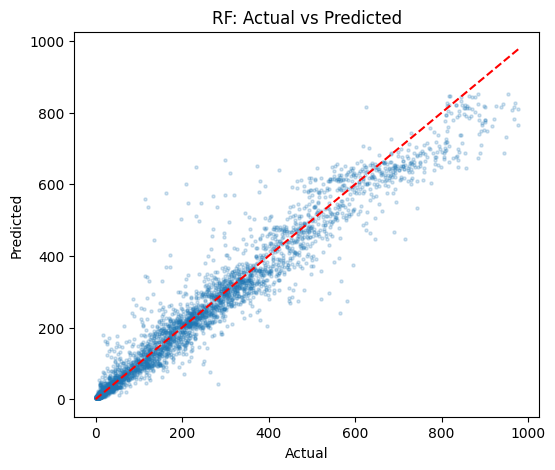

In [21]:
#Random Forest A vs P plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.2, s=5)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.title('RF: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

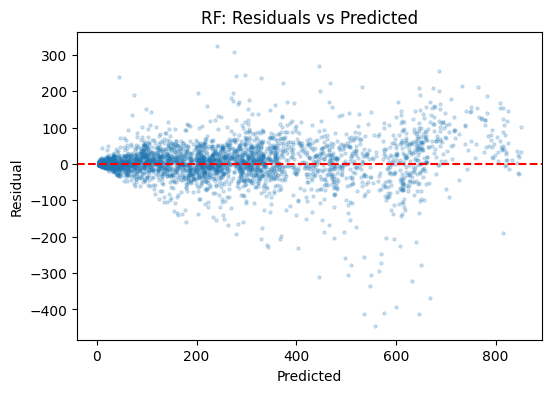

Residual mean: 5.3
Residual std:  54.66


In [22]:
#Residuals plot
residuals = y_test.values - y_pred_rf

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_rf, residuals, alpha=0.2, s=5)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('RF: Residuals vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.show()

print('Residual mean:', round(residuals.mean(), 2))
print('Residual std: ', round(residuals.std(), 2))

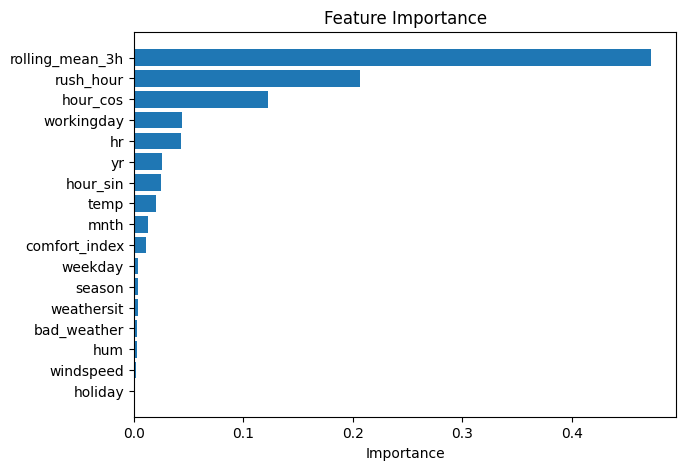

        feature  importance
rolling_mean_3h    0.471684
      rush_hour    0.206394
       hour_cos    0.122114
     workingday    0.043652
             hr    0.043188
             yr    0.025944
       hour_sin    0.024437
           temp    0.019779
           mnth    0.012833
  comfort_index    0.010776
        weekday    0.004103
         season    0.003980
     weathersit    0.003485
    bad_weather    0.002661
            hum    0.002469
      windspeed    0.002252
        holiday    0.000248


In [23]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance')

plt.figure(figsize=(7, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()

print(importance_df.sort_values('importance', ascending=False).to_string(index=False))

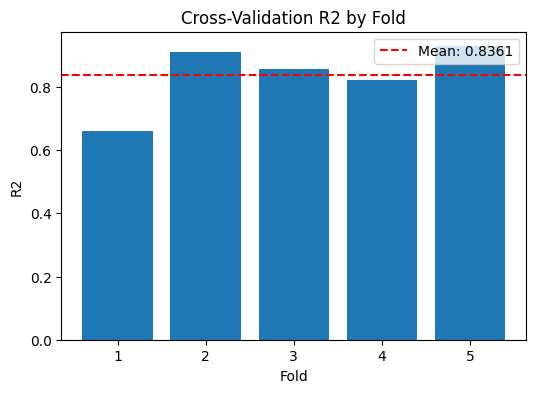

Cross-validation R2 scores:
  Fold 1: 0.6618
  Fold 2: 0.9115
  Fold 3: 0.8572
  Fold 4: 0.8219
  Fold 5: 0.9281
  Mean:   0.8361
  Std:    0.0951


In [24]:
#Cross validation
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_scores)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean: {cv_scores.mean():.4f}')
plt.title('Cross-Validation R2 by Fold')
plt.xlabel('Fold')
plt.ylabel('R2')
plt.legend()
plt.show()

print('Cross-validation R2 scores:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {round(s, 4)}')
print('  Mean:  ', round(cv_scores.mean(), 4))
print('  Std:   ', round(cv_scores.std(), 4))

## Model 2: SARIMA
Bike demand is time-ordered data with repeating daily and weekly patterns. SARIMA explicitly models autocorrelation and seasonality, which Random Forest only captures indirectly through engineered features.

In [25]:
ts = df_feat.set_index('datetime')['cnt'].resample('D').sum()
print('Daily series length:', len(ts))
print('Date range:', ts.index.min(), 'to', ts.index.max())

Daily series length: 731
Date range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00


In [26]:
adf = adfuller(ts)
print('ADF Statistic:', round(adf[0], 4))
print('p-value:      ', round(adf[1], 6))
print('Stationary:   ', 'Yes' if adf[1] < 0.05 else 'No')

ADF Statistic: -1.8774
p-value:       0.342743
Stationary:    No


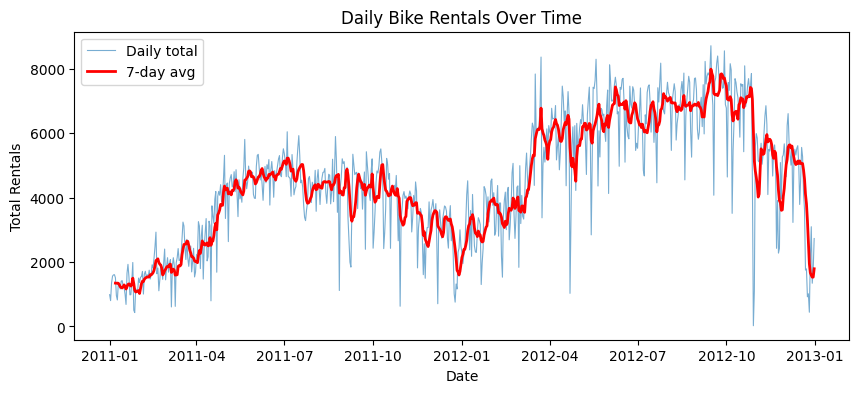

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, linewidth=0.8, alpha=0.6, label='Daily total')
plt.plot(ts.index, ts.rolling(7).mean(), linewidth=2, color='red', label='7-day avg')
plt.title('Daily Bike Rentals Over Time')
plt.xlabel('Date')
plt.ylabel('Total Rentals')
plt.legend()
plt.show()

In [28]:
n_test = 60
train_ts = ts.iloc[:-n_test]
test_ts  = ts.iloc[-n_test:]

print('Train days:', len(train_ts))
print('Test days: ', len(test_ts))

Train days: 671
Test days:  60


In [29]:
# SARIMA(1,1,1)(1,1,0)[7]
# Weekly seasonality (7-day period), first-order differencing for stationarity
sarima = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,0,7),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print('SARIMA trained')

SARIMA trained


In [30]:
forecast = sarima_fit.get_forecast(steps=n_test)
fc_mean  = forecast.predicted_mean
fc_ci    = forecast.conf_int(alpha=0.05)

mae_sarima  = mean_absolute_error(test_ts, fc_mean)
rmse_sarima = np.sqrt(mean_squared_error(test_ts, fc_mean))
r2_sarima   = r2_score(test_ts, fc_mean)

print('SARIMA Results (daily):')
print('  MAE: ', round(mae_sarima, 2))
print('  RMSE:', round(rmse_sarima, 2))
print('  R2:  ', round(r2_sarima, 4))

SARIMA Results (daily):
  MAE:  1948.6
  RMSE: 2428.28
  R2:   -1.3462


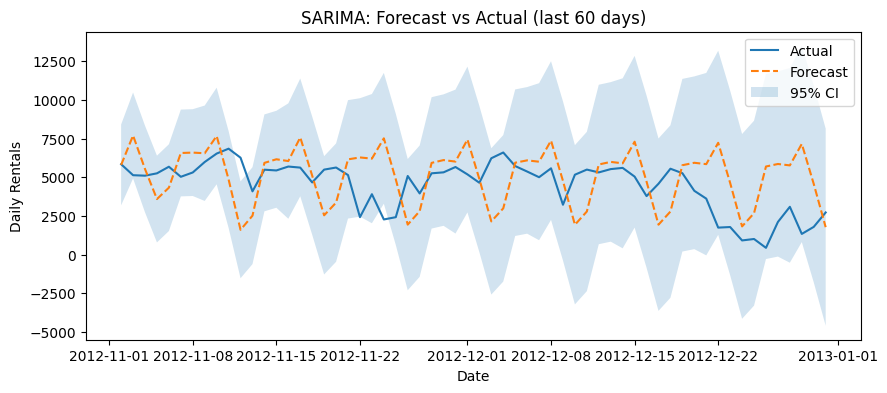

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(test_ts.index, test_ts.values, label='Actual')
plt.plot(fc_mean.index, fc_mean.values, linestyle='--', label='Forecast')
plt.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.2, label='95% CI')
plt.title('SARIMA: Forecast vs Actual (last 60 days)')
plt.xlabel('Date')
plt.ylabel('Daily Rentals')
plt.legend()
plt.show()

## Model Comparison

In [32]:
results = pd.DataFrame({
    'Model':       ['Random Forest', 'SARIMA'],
    'Granularity': ['Hourly',        'Daily'],
    'MAE':         [round(mae_rf, 2),    round(mae_sarima, 2)],
    'RMSE':        [round(rmse_rf, 2),   round(rmse_sarima, 2)],
    'R2':          [round(r2_rf, 4),     round(r2_sarima, 4)]
})

print(results.to_string(index=False))

        Model Granularity    MAE    RMSE      R2
Random Forest      Hourly   33.1   54.92  0.9380
       SARIMA       Daily 1948.6 2428.28 -1.3462


## Ethical Analysis

The dataset comes from Washington D.C. in 2011 and 2012 which means a model trained on it may not hold up in other cities with different climates or commuting habits. There is also no information on which neighborhoods the bikes came from, so the model has no way of knowing if certain areas are consistently underserved. If operators use predictions to decide where to put bikes, they could end up pulling resources from areas that already have less access.

The data is also over ten years old. Rider behavior, pricing, and infrastructure have all changed. This model should be retrained regularly rather than treated as a fixed solution.

This model should support decisions, not replace them. Unusual conditions like major events, extreme weather, or system outages will not be predicted well and operators should apply their own judgment in those cases.

## Business Recommendations

A few things stand out from the model results that operators could act on directly.

Demand on working days spikes hard at 8am and again around 5-6pm. Bikes need to be in place before those windows open, not redistributed during them. The rush_hour feature confirmed this pattern is consistent enough to plan around.

Rain and bad weather change significantly. When a bad weather day is forecast, scaling back deployment early saves effort without missing much real demand.

Fall had the highest average demand across both years. That is the right time to have maximum fleet size available with maintenance scheduled before rather than during peak season.

For day to day operations, Random Forest at the hourly level is the better tool. For planning staffing or fleet management a week or two out, SARIMA gives a reasonable weekly trend without needing fine-grained inputs.

## Analysis

**Approach:** Two models were built to predict bike rental demand. Random Forest used 17 features at the hourly level including 5 engineered variables. SARIMA modeled daily aggregated demand using only past values and weekly seasonality.

**Results:** Random Forest outperformed SARIMA on R2. This is expected because it has access to contextual features like weather, hour, and season, whereas SARIMA does not. The engineered feature rolling_mean_3h was the most important predictor, showing that recent demand is the best signal for current demand. rush_hour, comfort_index, hour_sin/cos, and bad_weather all ranked in the top half of feature importance, validating the engineering decisions.

**SARIMA** captured the weekly seasonal cycle reasonably well and is more interpretable for capacity planning, but it cannot incorporate weather or time of day context without adding more variables.

**Limitations:** Random Forest cannot plan beyond historical conditions. Both models were trained on 2011-2012 data and would need retraining over time. The dataset has no station-level information, so predictions are system-wide only.

**Next steps:**
- Add more weather variables to SARIMA (SARIMAX)
- Tune parameters with cross-validation grid search
- Expand to station-level predictions for operational use